In [1]:
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import simulation_cpu  as sim
import scipy.special as scp
import analyze_tool as an




In [ ]:
lamda = 8e-7 
time_cycal= lamda/sim.c
FWHM  = 10*time_cycal
sigma = (0.5/(np.log(2)** 0.5)) * FWHM 
max_E = 3e5
fea = np.pi/2
w = 2*np.pi/ time_cycal
safe_start = 3
norm = np.pi**0.5 * pulse_width/2 * np.exp(-pulse_width**2  * w**2) *(2*np.exp(pulse_width**2  * w**2)+ np.cos(2*fea) + 1)

dt = time_cycal


e_r = 2
sigma = 0
alpha = 0
ms0= np.array([0, 0 , 1])*1e4
len_matiral = 8*lamda


time_cut = 100
dt = time_cycal/time_cut
dz = 2*sim.c *dt


# spaece and time defntion
z1 = int(5*pulse_width/dt) +3
z2 = z1 + int(len_matiral/dz) 
lenz= z2 + time_cut//2



gassian gen verfiction


check power in
check 1- p = sum(heta0 * E^2)


plot the puls

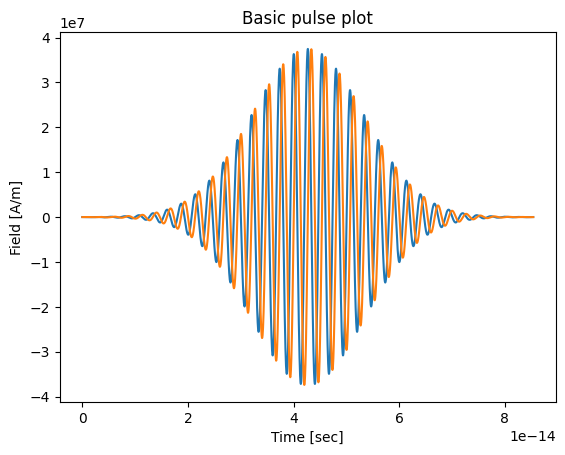

In [4]:
time_step = int(8*pulse_width/dt)
t = np.arange(time_step)
pulse =sim.pulse_gen(10000, np.pi/2, pulse_width, dt)
p_x =[]
p_y =[]
for n in t:
    p =pulse(n)
    p_y.append(p[1])
    p_x.append(p[0])

plt.plot(t*dt, np.real(p_x))
plt.plot(t*dt, np.real(p_y))
plt.title("Basic pulse plot")
plt.xlabel("Time [sec]")
plt.ylabel("Field [A/m]")
plt.show()



chack 1
enrgay in in = integral of heta*E^2 {J}

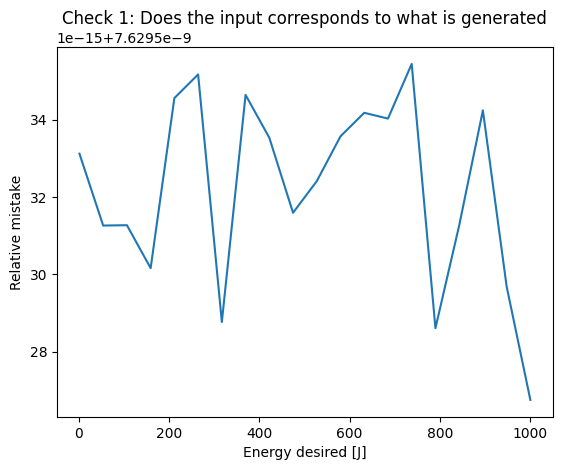

In [5]:
Pin_vec =np.linspace(2, 1000, 20)
step = int(10*pulse_width/dt)
t = np.arange(step)
real_p = []
abs_p = []
for p in Pin_vec:
    real_power = 0
    abs_power = 0
    pulse = sim.pulse_gen(p, np.pi/2,pulse_width, dt)
    for i in t:
        pulse_in_time = pulse(i)
        real_power += sum(np.real(pulse_in_time)**2)
        abs_power += sum(np.abs(pulse_in_time)**2)
    real_p.append(real_power)
    abs_p.append(abs_power)
real_p = np.array(real_p)*sim.heta*dt
abs_p = np.array(abs_p)*sim.heta*dt
check_real = (Pin_vec - real_p)/Pin_vec
check_abs = (Pin_vec - 0.5*abs_p)/Pin_vec
# print("check real mean error: ",  check_real)
# print("check abs mean error: ",  check_abs)
# print("check real mean error: ",  np.mean(check_real))
# print("check abs mean error: ",  np.mean(check_abs))

plt.plot(Pin_vec, check_real)
plt.title("Check 1: Does the input corresponds to what is generated")
plt.xlabel("Energy desired [J]")
plt.ylabel("Relative mistake")
plt.show()

    

check 2

does polarization change the power?
checks for what polriztion we make

conclusions:
as the polarization is more circulized, the power generated is closer to what it should be. 
we think this effect comes from the role that cos(fea) takes in the normalization.

<function matplotlib.pyplot.show(close=None, block=None)>

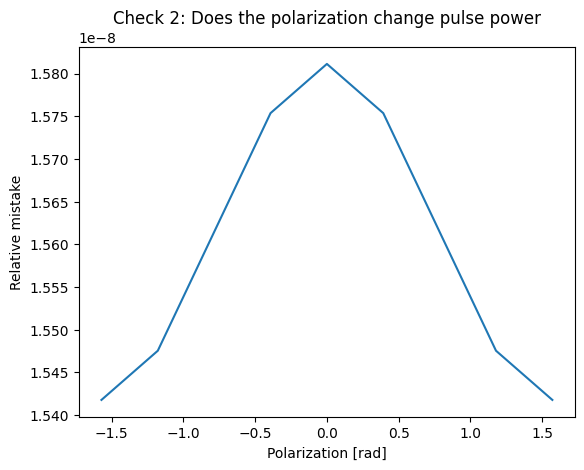

In [6]:
polarization = np.linspace(-np.pi/2, np.pi/2,9)
P_gen = np.zeros(np.size(polarization))
energy_in= 200 #in joule

for i, fea in enumerate(polarization):
    pulse = sim.pulse_gen(energy_in, fea, pulse_width, dt)
    for n in range(time_step):
        p = pulse(n) 
        P_gen[i] += sum(np.real(p)**2)* sim.heta*dt
    # fv= [pulse(1,:);pulse(2,:)];
    # [tau,epsilon] =np.polellip(fv);
    # t= dt * (1:length(pulse));
    # plot(t,epsilon, "DisplayName" , num2str(i))

check2 = (energy_in -P_gen)/energy_in
check2_mean_error = np.mean(check2)
# print("check 2 real error: ", check2)
# print("check 2 real mean error: ", check2_mean_error)
# print("check 2 error reng size: ", max(check2)-min(check2))

plt.plot(polarization, check2)
plt.title("Check 2: Does the polarization change pulse power")
plt.xlabel("Polarization [rad]")
plt.ylabel("Relative mistake")
plt.show    





% check 3 
does the pulse width change the power?

conclusions:
very small error. As the pulse gets wider the error is a little bit bigger and stablizes at 7.7e-9 - this factor also comes from the normalization that rounds itself down by a little, and the wider we are we get it effect stronger.

<function matplotlib.pyplot.show(close=None, block=None)>

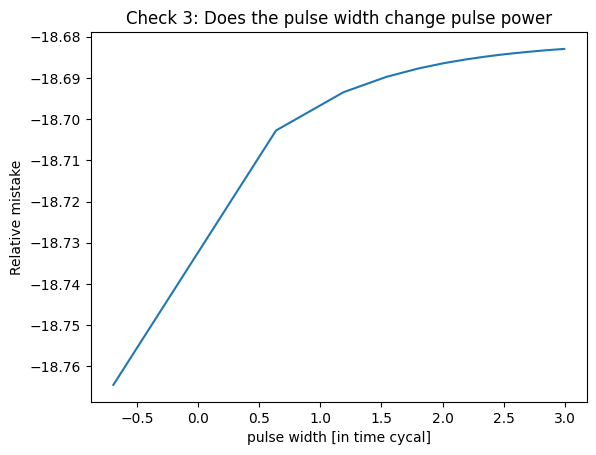

In [9]:

pulse_width = np.linspace(0.5, 20 , 15) * time_cycal
P_gen = np.zeros(np.size(pulse_width))
energy_in= 200 # joule
for i , width in enumerate(pulse_width):
    pules = sim.pulse_gen(energy_in, np.pi/2, width, dt)
    steps_i = 10* int(width/dt) 
    for n in range(steps_i):
        p = pules(n) 
        P_gen[i] += sum(np.real(p)**2)* sim.heta*dt

check3 = (energy_in - P_gen)/energy_in
check3_mean_error = np.mean(check3)

plt.plot(np.log(pulse_width/time_cycal), np.log(check3))
plt.xlabel("pulse width [in time cycal]")
plt.title("Check 3: Does the pulse width change pulse power")
plt.ylabel("Relative mistake")
plt.show
# print("mean error is :",check3_mean_error)

check 4
does the time_cut change the power?

not much, As the time cut gets bigger, the error is a little bit bigger and stablizes at 7.7e-9 - same factor as in check 3.

mean error is : 7.668645719484309e-09


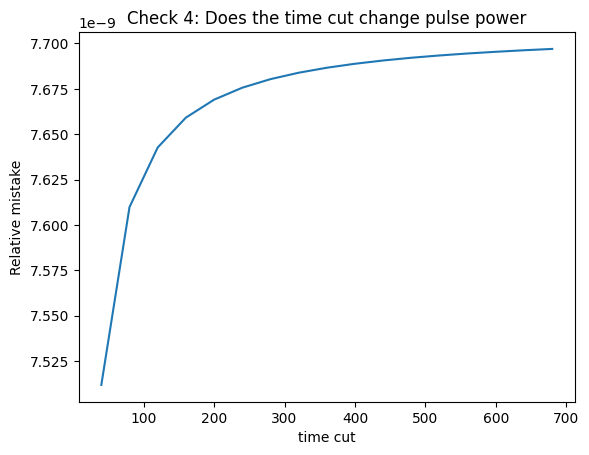

In [12]:
time_cuts =np.array([40 +i*40  for i in range(17)])
pulse_width = 4* time_cycal
P_gen = []

energy_in= 200 # joule
for i , t_cut in enumerate(time_cuts):
    P_gen.append(0)
    dt  = time_cycal/ t_cut
    pules = sim.pulse_gen(energy_in, np.pi/2, pulse_width, dt)
    steps_i = 10* int(width/dt) 
    for n in range(steps_i):
        p = pules(n) 
        P_gen[i] += sum(np.real(p)**2)* sim.heta*dt

P_gen = np.array(P_gen)
check4 = (energy_in -P_gen)/energy_in
check4_mean_error = np.mean(check4)

plt.plot((time_cuts), (check4))
plt.xlabel("time cut")
plt.title("Check 4: Does the time cut change pulse power")
plt.ylabel("Relative mistake")
# print("mean error is :",check4_mean_error)


In [14]:

lamda0 = 8e-7 
time_cycal= lamda/sim.c
FWHM  = 10*time_cycal
sigma = (0.5/(np.log(2)** 0.5)) * FWHM 
max_E = 3e5
fea = np.pi/2
w = 2*np.pi/ time_cycal
safe_start = 5
x = (sigma**2)  * (w**2)
# norm = np.pi**0.5 * sigma/2 * np.exp(-x) *(2*np.exp(x)+ np.cos(2*fea) + 1)

print(np.exp(x))
dt = time_cycal/ np.arange(40,200,10)
max_time = int(2*safe_start*sigma)

inf


C:\Users\owner\AppData\Local\Temp\ipykernel_22496\2340767308.py:12: RuntimeWarning: overflow encountered in exp
  print(np.exp(x))


In [10]:
pules = sim.pulse_gen(1,fea, FWHM, dt[0], lamda= lamda0, start_sefty= safe_start)

E = 0
for n in range(max_time):
    filed = pules(n)
    E += (filed[0]**2 + filed[1]**2)
print(norm)

nan
